In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [ ]:
def golden_cross_strategy(ticker, start_date, end_date, short_window=20, long_window=60):
    """
    Golden Cross Trading Strategy Implementation

    Parameters:
    - ticker: Stock symbol (e.g., 'AAPL')
    - start_date: Start date in 'YYYY-MM-DD' format
    - end_date: End date in 'YYYY-MM-DD' format
    - short_window: Days for short moving average (default 50)
    - long_window: Days for long moving average (default 200)
    """

    # Download historical data
    #data = yf.download(ticker, start=start_date, end=end_date)
    # We download the stock price from start date until end date
    data = yf.download(ticker, start=start_date, end=end_date)
    print(data)


    if data.empty:
        print(f"No data found for {ticker}")
        return

    # Calculate moving averages
    data['SMA_Short'] = data['Close'].rolling(window=short_window, min_periods=1).mean()
    data['SMA_Long'] = data['Close'].rolling(window=long_window, min_periods=1).mean()

    # Generate signals
    data['Signal'] = 0
    #data['Signal'][short_window:] = np.where(data['SMA_Short'][short_window:] > data['SMA_Long'][short_window:], 1, 0)
    data['Signal'] = np.where(data['SMA_Short'] > data['SMA_Long'], 1, 0)

    # Calculate positions (difference in signals to identify crossovers)
    data['Position'] = data['Signal'].diff()


    # Initialize portfolio
    initial_capital = 100000.0
    positions = pd.DataFrame(index=data.index).fillna(0.0)
    portfolio = pd.DataFrame(index=data.index).fillna(0.0)

    # Buy/long 100 shares when golden cross occurs
    positions[ticker] = 100 * data['Signal']
    portfolio['holdings'] = positions.multiply(data['Close'], axis=0)
    portfolio['cash'] = initial_capital - (positions.diff().multiply(data['Close'], axis=0)).cumsum()
    portfolio['total'] = portfolio['cash'] + portfolio['holdings']
    portfolio['returns'] = portfolio['total'].pct_change()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(data['Close'], label='Price', alpha=0.5)
    plt.plot(data['SMA_Short'], label=f'{short_window}-day SMA', alpha=0.75)
    plt.plot(data['SMA_Long'], label=f'{long_window}-day SMA', alpha=0.75)

    # Plot golden cross buy signals
    plt.plot(data[data['Position'] == 1].index, data['SMA_Short'][data['Position'] == 1], '^', markersize=10, color='g', label='Golden Cross (Buy)')

    # Plot death cross sell signals (optional)
    plt.plot(data[data['Position'] == -1].index, data['SMA_Short'][data['Position'] == -1], 'v', markersize=10, color='r', label='Death Cross (Sell)')

    plt.title(f'{ticker} Golden Cross Trading Strategy')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid()
    plt.show()

    # Print strategy performance
    total_return = ((portfolio['total'][-1] / initial_capital) - 1) * 100
    print(f"\nStrategy Performance for {ticker} from {start_date} to {end_date}")
    print(f"Initial Capital: ${initial_capital:,.2f}")
    print(f"Final Portfolio Value: ${portfolio['total'][-1]:,.2f}")
    print(f"Total Return: {total_return:.2f}%")

    return data, portfolio

/tmp/ipython-input-3-3156168761.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2020-06-01   59.873333   59.933334   56.939999   57.200001  224092500
2020-06-02   58.770668   60.577332   58.066666   59.646667  203484000
2020-06-03   58.863998   59.862667   58.673332   59.208000  119242500
2020-06-04   57.625332   59.716667   57.229332   59.325333  133315500
2020-06-05   59.043999   59.101334   57.746666   58.522667  117178500
...                ...         ...         ...         ...        ...
2025-06-24  340.470001  356.260010  340.440002  356.170013  114736200
2025-06-25  327.549988  343.000000  320.399994  342.700012  119845100
2025-06-26  325.779999  331.049988  323.609985  324.609985   80440900
2025-06-27  323.630005  329.339996  317.500000  324.510010   89067000
2025-06-30  317.660004  325.579987  316.600006  319.899994   74472400

[1277 rows x 5 colu

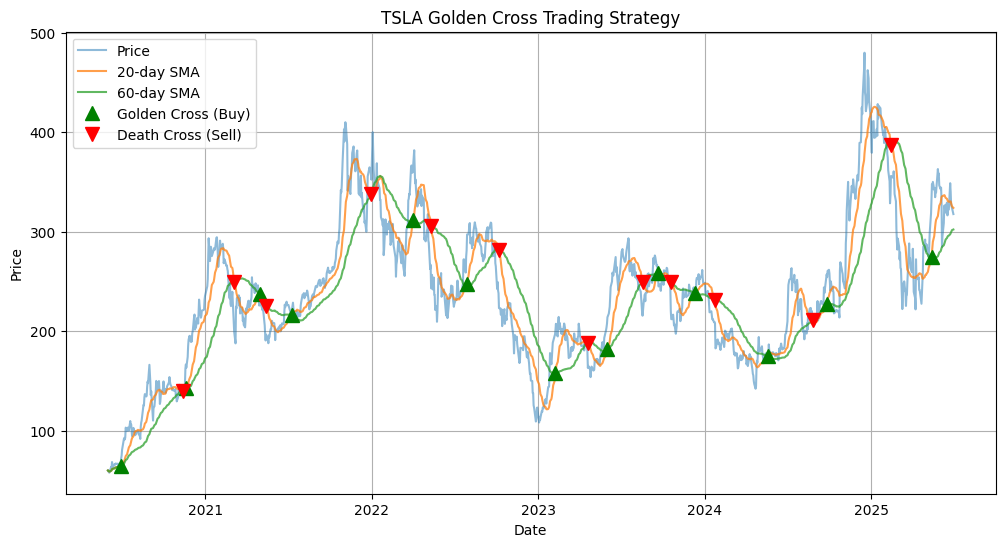


Strategy Performance for TSLA from 2020-06-01 to 2025-07-01
Initial Capital: $100,000.00
Final Portfolio Value: $106,353.00
Total Return: 6.35%


/tmp/ipython-input-3-3156168761.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_return = ((portfolio['total'][-1] / initial_capital) - 1) * 100
/tmp/ipython-input-3-3156168761.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Final Portfolio Value: ${portfolio['total'][-1]:,.2f}")


In [ ]:
stock_code = 'TSLA'
start_date = '2020-06-01'
end_date = '2025-07-01'
data, portfolio = golden_cross_strategy(stock_code, start_date, end_date)